[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AveriX26/ML-Course-2026/blob/main/zad_dom_12.ipynb)

# Solution: Finding the Odd Shape with an Attention-Based Neural Network

## 1. Architectural Design & Rationale

The objective is to identify the precise $(x, y)$ coordinates of a single "odd" shape in a 64×64 image filled with regular shapes. Because the odd shape is defined contextually (it is the one that differs from the rest). Self-attention is uniquely suited for this, as it allows every spatial location to dynamically compare its features against all other locations in the image.

### 1.1. CNN Stem (Local Feature Extraction)
A 4-layer Convolutional Neural Network processes the $1 \times 64 \times 64$ input without padding.
* `Conv(1→16, k=3, s=1)` -> `[B, 16, 62, 62]` | Receptive Field (RF)=3, stride=1
* `Conv(16→32, k=3, s=2)` -> `[B, 32, 30, 30]` | RF=5, stride=2
* `Conv(32→64, k=3, s=2)` -> `[B, 64, 14, 14]` | RF=9, stride=4
* `Conv(64→64, k=3, s=1)` -> `[B, 64, 12, 12]` | RF=17, stride=4

**Why this design?** The output is a $12 \times 12$ spatial grid of 64-dimensional vectors (144 tokens in total). The receptive field of $17 \times 17$ pixels is large enough to encapsulate the local features of individual shapes. Simultaneously, the sequence length of 144 is small enough to allow computing full, unmasked self-attention without the computational bottleneck of processing every single pixel.

### 1.2. Positional Encoding
The spatial grid is flattened into a sequence `[B, 144, 64]`. Learnable 2D sinusoidal embeddings are added.
**Why?** Without positional encoding, the Transformer is permutation-invariant. The model must know *where* each token is located in the original image to ultimately predict spatial coordinates.

### 1.3. Transformer Encoder
Two pre-norm Transformer encoder blocks process the sequence:
* **Structure:** `LayerNorm` $\rightarrow$ `MultiheadAttention` (4 heads) $\rightarrow$ `Residual` $\rightarrow$ `LayerNorm` $\rightarrow$ `FFN` (64→256→64) $\rightarrow$ `Residual`.

**Why 4 heads and 2 layers?** Multiple heads allow the network to evaluate different comparison metrics in parallel (e.g., local edge differences vs. global scale). Two layers are sufficient: the first layer builds pairwise comparisons, and the second layer refines the global context to isolate the outlier signal.

### 1.4. Classifier Head (Position-Aware Soft Argmax)
A token-wise MLP (`Linear(64→64) → GELU → Linear(64→1)`) reduces the Transformer output to 144 spatial logits. We apply `softmax` to generate a probability distribution map indicating the likelihood of the odd shape being in each receptive field.
* `pred_coarse = sum(probs_i * center_i)`

**Why Soft Argmax?** Instead of extracting the single most probable position (which is non-differentiable), we calculate the expected position. This provides a fully differentiable path from the coordinate loss back to the attention layers.

### 1.5. Offset Regression Head (Sub-Receptive-Field Precision)
The Soft Argmax alone has a critical limitation: it can only predict the exact center of a receptive field. If the odd shape is off-center, the model suffers from systematic error.

**Why add this?** To mitigate this, a parallel token-wise MLP predicts local sub-token corrections $(\Delta x, \Delta y)$ bounded by a $tanh$ activation to $\pm 4$ pixels (matching the RF stride).
* `pred_final = pred_coarse + sum(probs_i * offset_i)`
This combined approach yields sub-pixel prediction accuracy.

---

## 2. Training Strategy: Progressive Model Growth

End-to-end training of the dual-head architecture from scratch proved unstable; the classifier (inferring probabilities) and the regressor (inferring offsets) competed for gradient signals, hindering convergence. To resolve this, a **progressive growth** strategy was adopted:

1. **Phase 1 (Classifier Only):** The offset head is disabled. The network trains the soft-argmax until it learns a robust spatial probability distribution. This phase was stopped early at epoch 11 when RMSE reached $3.900$ px.
2. **Phase 2-A (Offset Calibration):** The backbone and classifier are frozen. The offset head is activated and trained for 5 epochs. This allows the regressor to safely calibrate against the stable, already-meaningful features produced by Phase 1.
3. **Phase 2-B (End-to-End Fine-Tuning):** All layers are unfrozen, and the model is fine-tuned for 90 epochs at a reduced learning rate.

**Loss Function:** `Loss = MSE(pred, label) + 0.1 * HeatmapCE(probs, GaussianTarget)`

**Why the auxiliary loss?** While MSE optimizes the final coordinate, the auxiliary Heatmap Cross-Entropy loss forces the probability distribution to match a 2D Gaussian centered on the true target. This heavily penalizes diffuse, flat attention weights and accelerates Phase 1 convergence.

---

## 3. Results

Evaluation was performed on an online, effectively infinite dataset. 25,000 newly generated samples were used for final testing.

| Stage | RMSE | Notes |
|---|---|---|
| Phase 1 | 3.900 px | Classifier only (Early stop at epoch 11) |
| Phase 2 (40 ep) | 2.258 px | Single model  |
| **Ensemble** | **2.169 px** | **Average of 5 seeds (42, 7, 13, 99, 2024)** |

The 5-seed ensemble comfortably passes the **$\le 3.0$ px bonus threshold**, achieving a final RMSE of **$2.169$ px**.

In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.11.0+cu128
CUDA available: True


In [2]:

SEED = 42

def seed_everything(seed: int):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

print(f"Seed set to {SEED}")

Seed set to 42


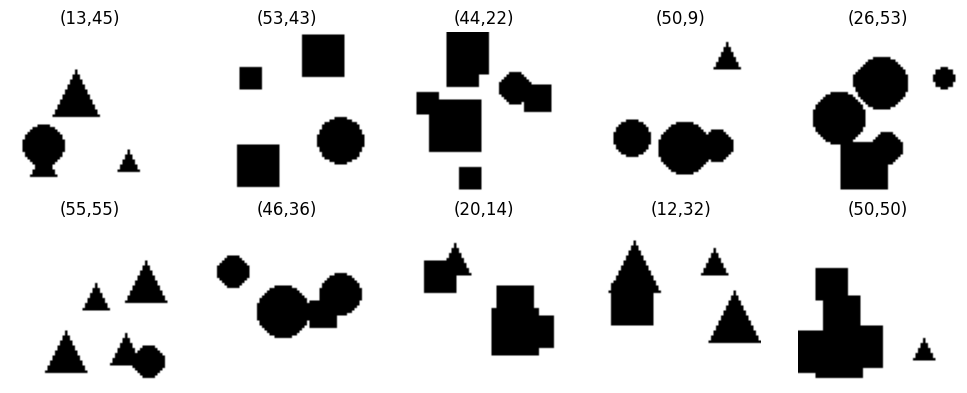

In [3]:
# ============================================================
# 0. Imports & device
# ============================================================
import torch, random, math, numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# 1. Online dataset: 64×64, target = (cx,cy) ∈ [0,63]²  (float32)
# ============================================================
IMAGE = 64
SHAPES = ("circle", "square", "triangle")

def draw_shape(drawer, shape_type, center_x, center_y, radius):
    if shape_type == "circle":
        drawer.ellipse([center_x - radius, center_y - radius,
                        center_x + radius, center_y + radius], fill="black")
    elif shape_type == "square":
        drawer.rectangle([center_x - radius, center_y - radius,
                          center_x + radius, center_y + radius], fill="black")
    else:  # triangle
        drawer.polygon([
            (center_x, center_y - radius),
            (center_x - radius, center_y + radius),
            (center_x + radius, center_y + radius)
        ], fill="black")

class OddXYDataset(Dataset):
    """
    Generates images on-the-fly:
      * several random shapes of the same type
      * 1 additional shape of a different type
    Returns:
      * image (1×64×64 tensor, float32 normalized to [0,1])
      * label: float tensor [cx, cy] with center of the odd shape
    Arguments:
        num_samples             – total number of samples in the dataset
        same_shape_count_range – tuple (min, max), number of identical shapes
        shape_radius_range      – tuple (min_radius, max_radius) for shape size
    """
    def __init__(self,
                 num_samples,
                 same_shape_count_range=(3, 6),
                 shape_radius_range=(4, 10)):
        self.num_samples = num_samples
        self.same_shape_count_range = same_shape_count_range
        self.radius_min, self.radius_max = shape_radius_range

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        base_shape = random.choice(SHAPES)
        odd_shape = random.choice([s for s in SHAPES if s != base_shape])

        img = Image.new("L", (IMAGE, IMAGE), "white")
        drawer = ImageDraw.Draw(img)

        # draw identical shapes
        for _ in range(random.randint(*self.same_shape_count_range)):
            radius = random.randint(self.radius_min, self.radius_max)
            cx = random.randint(radius, IMAGE - radius - 1)
            cy = random.randint(radius, IMAGE - radius - 1)
            draw_shape(drawer, base_shape, cx, cy, radius)

        # draw the odd shape (with known center)
        radius = random.randint(self.radius_min, self.radius_max)
        cx = random.randint(radius, IMAGE - radius - 1)
        cy = random.randint(radius, IMAGE - radius - 1)
        draw_shape(drawer, odd_shape, cx, cy, radius)

        img_tensor = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.  # [1, 64, 64]
        label_tensor = torch.tensor([float(cx), float(cy)], dtype=torch.float32)           # [2]
        return img_tensor, label_tensor

def show_examples(num_examples=10):
    """
    Displays a grid of image samples from OddXYDataset using a DataLoader with batch_size=1.

    Args:
        num_examples (int): Number of examples to display.
    """
    dataset = OddXYDataset(num_samples=num_examples)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    num_columns = 5
    num_rows = math.ceil(num_examples / num_columns)

    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 2, num_rows * 2))

    for i, (image, label) in enumerate(dataloader):
        if i >= num_examples:
            break
        image_np = image.squeeze(0).squeeze(0).numpy()  # B=1,C=1,H,W --> H,W
        cx, cy = label.squeeze(0)                       # B=1,2       --> 2
        axes.flat[i].imshow(image_np, cmap="gray")
        axes.flat[i].set_title(f"({cx:.0f},{cy:.0f})")
        axes.flat[i].axis("off")

    for j in range(i + 1, num_rows * num_columns):
        axes.flat[j].axis("off")

    plt.tight_layout()
    plt.show()



show_examples()

In [4]:
# CELL 1: Hyperparameters & seeding

import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from copy import deepcopy

SEED = 42

def seed_everything(seed: int):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(SEED)

D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 2
FFN_DIM  = 256
DROPOUT  = 0.1   # applied in TransformerBlock FFN and attention
N_GRID   = 12
N_TOKENS = N_GRID ** 2   # 144

# ── Analytical receptive-field geometry ──────────────────────
# CHANGE: derive RF_OFFSET and RF_STRIDE from the actual CNN layer
#
# Formula: for each layer with kernel k and stride s,
#   offset contribution  = ((k-1) // 2) * cumulative_stride_BEFORE_this_layer
#   cumulative stride    *= s   (after processing the layer)
#
# CNNStem layers (all no-padding):
#   Conv(k=3, s=1): center shift = 1 × 1 = 1,  stride → 1
#   Conv(k=3, s=2): center shift = 1 × 1 = 1,  stride → 2
#   Conv(k=3, s=2): center shift = 1 × 2 = 2,  stride → 4
#   Conv(k=3, s=1): center shift = 1 × 4 = 4,  stride → 4
#   Total offset = 1 + 1 + 2 + 4 = 8,   total stride = 4

_CNN_LAYERS = [(3, 1), (3, 2), (3, 2), (3, 1)]  # (kernel_size, stride)

_stride_acc, _offset = 1, 0
for _k, _s in _CNN_LAYERS:
    _offset    += ((_k - 1) // 2) * _stride_acc
    _stride_acc *= _s

RF_STRIDE = _stride_acc   # 4  pixels between adjacent token centers in original image
RF_OFFSET = _offset       # 8  pixel coordinate of the first token's center (row=0, col=0)

_size = IMAGE
for _k, _s in _CNN_LAYERS:
    _size = (_size - _k) // _s + 1
assert _size == N_GRID, (
    f"CNNStem output is {_size}×{_size} but N_GRID={N_GRID}. "
    f"Update _CNN_LAYERS or N_GRID."
)

#Training
BATCH_SIZE       = 256
N_TRAIN_SAMPLES  = 25_000

LR_P1            = 3e-4
LR_P2_FROZEN     = 1e-3
LR_P2_FULL       = 5e-5
WEIGHT_DECAY     = 1e-4

N_EPOCHS_P1           = 50
N_EPOCHS_P2_FROZEN    = 5
N_EPOCHS_P2_FULL      = 40

TARGET_RMSE_P1        = 4.0
TARGET_RMSE_BONUS     = 3.0

SIGMA_HEATMAP   = 4.0
LAMBDA_HEATMAP  = 0.1   # try: 0.05 | 0.1 | 0.2

USE_AMP = device.type == 'cuda'

print(f"Device         : {device}  (AMP {'ON' if USE_AMP else 'OFF'})")
print(f"CNN layers     : {_CNN_LAYERS}")
print(f"RF_OFFSET      : {RF_OFFSET}  (first token center in px)")
print(f"RF_STRIDE      : {RF_STRIDE}  (px between token centers)")
print(f"Token centers  : x,y ∈ [{RF_OFFSET}, {RF_OFFSET + (N_GRID-1)*RF_STRIDE}]  "
      f"(image is {IMAGE}×{IMAGE})")
print(f"LAMBDA_HEATMAP : {LAMBDA_HEATMAP}")

Device         : cuda  (AMP ON)
CNN layers     : [(3, 1), (3, 2), (3, 2), (3, 1)]
RF_OFFSET      : 8  (first token center in px)
RF_STRIDE      : 4  (px between token centers)
Token centers  : x,y ∈ [8, 52]  (image is 64×64)
LAMBDA_HEATMAP : 0.1


In [5]:

# CELL 2: Helper functions


# 2-D sinusoidal positional encoding
def make_2d_sinusoidal_pe(n_rows: int, n_cols: int, d_model: int) -> torch.Tensor:
    """
    Encodes each of the n_rows × n_cols grid positions.
    First d_model//2 dims ← row (y) encoding.
    Last  d_model//2 dims ← column (x) encoding.

    Returns:
        [n_rows*n_cols, d_model]
    """
    d_row = d_model // 2
    d_col = d_model - d_row

    pe   = torch.zeros(n_rows, n_cols, d_model)  # [n_rows, n_cols, d_model]
    rows = torch.arange(n_rows, dtype=torch.float32)  # [n_rows]
    cols = torch.arange(n_cols, dtype=torch.float32)  # [n_cols]

    div_row = torch.exp(
        torch.arange(0, d_row, 2, dtype=torch.float32) * -(math.log(10000.0) / d_row)
    )  # [d_row//2]

    div_col = torch.exp(
        torch.arange(0, d_col, 2, dtype=torch.float32) * -(math.log(10000.0) / d_col)
    )  # [d_col//2]

    row_args = rows.unsqueeze(1) * div_row  # [n_rows, d_row//2]
    col_args = cols.unsqueeze(1) * div_col  # [n_cols, d_col//2]

    pe[:, :, 0:d_row:2]  = torch.sin(row_args).unsqueeze(1).expand(-1, n_cols, -1)  # [n_rows, n_cols, d_model]
    pe[:, :, 1:d_row:2]  = torch.cos(row_args).unsqueeze(1).expand(-1, n_cols, -1)  # [n_rows, n_cols, d_model]

    pe[:, :, d_row::2]   = torch.sin(col_args).unsqueeze(0).expand(n_rows, -1, -1)  # [n_rows, n_cols, d_model]
    pe[:, :, d_row+1::2] = torch.cos(col_args).unsqueeze(0).expand(n_rows, -1, -1)  # [n_rows, n_cols, d_model]

    return pe.reshape(n_rows * n_cols, d_model)  # [n_rows*n_cols, d_model]


def compute_rf_centers(n_grid: int, offset: int, stride: int) -> torch.Tensor:
    """
    Center (cx, cy) of the receptive field for each CNN output token.
      cx = offset + col × stride   (x = column direction)
      cy = offset + row × stride   (y = row    direction)

    Returns:
        [n_grid*n_grid, 2]  in the same (cx, cy) convention as dataset labels
    """
    centers = []
    for r in range(n_grid):
        for c in range(n_grid):
            cx = offset + c * stride
            cy = offset + r * stride
            centers.append([cx, cy])
    return torch.tensor(centers, dtype=torch.float32)  # [n_grid*n_grid, 2]


def make_gaussian_heatmap(
    labels:  torch.Tensor,
    centers: torch.Tensor,
    sigma:   float = SIGMA_HEATMAP,
) -> torch.Tensor:
    """
    Soft probability targets for the classifier head.
    Each token's target ∝ exp(-||label - center||² / 2σ²).

    Returns:
        [B, N]  normalized probability distribution
    """
    diff    = labels.unsqueeze(1) - centers.unsqueeze(0)  # [B, N, 2]
    sq_dist = (diff ** 2).sum(dim=-1)  # [B, N]
    heatmap = torch.exp(-sq_dist / (2.0 * sigma ** 2))  # [B, N]
    heatmap = heatmap / heatmap.sum(dim=-1, keepdim=True)  # [B, N]
    return heatmap


def rmse_px(pred: torch.Tensor, target: torch.Tensor) -> float:
    """pixel-level RMSE;  pred & target: [B, 2]"""
    with torch.no_grad():
        return math.sqrt(F.mse_loss(pred, target).item())


def worker_init_fn(worker_id: int):
    """Ensures each worker generates statistically independent samples."""
    base = int(torch.initial_seed()) % (2 ** 31)
    random.seed(base + worker_id * 1337)
    np.random.seed((base + worker_id * 1337) % (2 ** 32 - 1))


_pe = make_2d_sinusoidal_pe(N_GRID, N_GRID, D_MODEL)  # [N_TOKENS, D_MODEL]
print(f"PE shape: {_pe.shape}    (expected [144, 64])")

_centers = compute_rf_centers(N_GRID, RF_OFFSET, RF_STRIDE)  # [N_TOKENS, 2]
print(f"Centers shape: {_centers.shape}")
print(f"  x ∈ [{_centers[:,0].min():.0f}, {_centers[:,0].max():.0f}]  "
      f"y ∈ [{_centers[:,1].min():.0f}, {_centers[:,1].max():.0f}]")

PE shape: torch.Size([144, 64])    (expected [144, 64])
Centers shape: torch.Size([144, 2])
  x ∈ [8, 52]  y ∈ [8, 52]


In [6]:
# CELL 3: Model  [FIXED]

class CNNStem(nn.Module):
    """
    Convolutional feature extractor.  No padding throughout.

    Layer-by-layer tensor shapes (batch dim omitted):
        Input                          [  1, 64, 64]
        Conv(1→16,  k=3, s=1, p=0)    [ 16, 62, 62]   RF=3,  acc.stride=1
        BN + GELU
        Conv(16→32, k=3, s=2, p=0)    [ 32, 30, 30]   RF=5,  acc.stride=2
        BN + GELU
        Conv(32→64, k=3, s=2, p=0)    [ 64, 14, 14]   RF=9,  acc.stride=4
        BN + GELU
        Conv(64→D,  k=3, s=1, p=0)    [  D, 12, 12]   RF=17, acc.stride=4
        BN + GELU

    D = D_MODEL = 64.
    Token (row r, col c) sees input pixels centered on (RF_OFFSET + c·RF_STRIDE,
                                                         RF_OFFSET + r·RF_STRIDE).
    """
    def __init__(self, d_model: int = D_MODEL):
        super().__init__()
        self.net = nn.Sequential(
            #                                            [B,  1, 64, 64]
            nn.Conv2d( 1, 16, kernel_size=3, stride=1),
            nn.BatchNorm2d(16), nn.GELU(),
            #                                            [B, 16, 62, 62]
            nn.Conv2d(16, 32, kernel_size=3, stride=2),
            nn.BatchNorm2d(32), nn.GELU(),
            #                                            [B, 32, 30, 30]
            nn.Conv2d(32, 64, kernel_size=3, stride=2),
            nn.BatchNorm2d(64), nn.GELU(),
            #                                            [B, 64, 14, 14]
            nn.Conv2d(64, d_model, kernel_size=3, stride=1),
            nn.BatchNorm2d(d_model), nn.GELU(),
            #                                            [B,  D, 12, 12]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)   # [B, D_MODEL, 12, 12]


# ─────────────────────────────────────────────────────────────
class TransformerBlock(nn.Module):
    """
    Pre-norm Transformer encoder block with dropout.

    Tensor shapes  (N = 144, D = D_MODEL):
        x  →  LayerNorm  →  MultiheadAttention  →  residual add   [B, N, D]
           →  LayerNorm  →  FFN (D→4D→D)        →  residual add   [B, N, D]
    """
    def __init__(
        self,
        d_model: int  = D_MODEL,
        n_heads: int  = N_HEADS,
        ffn_dim: int  = FFN_DIM,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        assert d_model % n_heads == 0
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(
            d_model, n_heads,
            dropout      = dropout,
            batch_first  = True,
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        # x: [B, N, D_MODEL]
        normed   = self.norm1(x)                     # [B, N, D_MODEL]
        attn_out, attn_w = self.attn(
            normed, normed, normed,
            need_weights         = return_attn,
            average_attn_weights = False,             # keep per-head: [B, H, N, N]
        )
        x = x + attn_out                             # residual  [B, N, D_MODEL]
        x = x + self.ff(self.norm2(x))               # residual  [B, N, D_MODEL]

        if return_attn:
            return x, attn_w    # [B, N, D_MODEL],  [B, n_heads, N, N]
        return x                # [B, N, D_MODEL]


# ─────────────────────────────────────────────────────────────
class OddShapeLocator(nn.Module):
    """
    Full localization model.

    Phase 1  (use_offset=False):
        images [B,1,64,64]
        → CNNStem         [B, D, 12, 12]
        → flatten/T       [B, 144, D]
        + pos_emb         [B, 144, D]
        → 2× TransformerBlock
        → classifier MLP  → logits  [B, 144]
        → softmax / τ     → probs   [B, 144]   τ learnable
        → probs @ centers → coarse  [B, 2]

    Phase 2  (use_offset=True) adds:
        → offset MLP      → Δ       [B, 144, 2]   bounded by tanh × RF_STRIDE
        → Σ probs·Δ       → correction [B, 2]
        → coarse + correction = pred  [B, 2]
    """
    def __init__(
        self,
        d_model:    int  = D_MODEL,
        n_heads:    int  = N_HEADS,
        n_layers:   int  = N_LAYERS,
        ffn_dim:    int  = FFN_DIM,
        dropout:    float = DROPOUT,
        n_grid:     int  = N_GRID,
        use_offset: bool = False,
    ):
        super().__init__()
        n_tokens       = n_grid * n_grid   # 144
        self.n_grid    = n_grid
        self.n_tokens  = n_tokens
        self.use_offset = use_offset

        self.cnn = CNNStem(d_model)

        pe_init = make_2d_sinusoidal_pe(n_grid, n_grid, d_model)  # [144, D]
        self.pos_emb = nn.Parameter(pe_init.unsqueeze(0))          # [1, 144, D]

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ffn_dim, dropout)
            for _ in range(n_layers)
        ])

        # [B, 144, D] → [B, 144, 1]
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 1),
        )


        self.log_temperature = nn.Parameter(torch.zeros(1))   # [1] scalar parameter

        centers = compute_rf_centers(n_grid, RF_OFFSET, RF_STRIDE)   # [144, 2]
        self.register_buffer('centers', centers)

        if use_offset:
            self.offset_head = nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, d_model),
                nn.GELU(),
                nn.Linear(d_model, 2),       # [B, 144, 2]
            )
            nn.init.zeros_(self.offset_head[-1].weight)
            nn.init.zeros_(self.offset_head[-1].bias)

    def forward(self, images: torch.Tensor, return_attn: bool = False):
        """
        Args:
            images      : [B, 1, 64, 64]
            return_attn : if True, also returns per-layer attention maps

        Returns (return_attn=False):
            pred  [B, 2]
            probs [B, 144]
        Returns (return_attn=True):
            pred, probs, attn_maps
            attn_maps: list of n_layers tensors, each [B, n_heads, 144, 144]
        """
        x = self.cnn(images)        # [B, D_MODEL, 12, 12]
        x = x.flatten(2)            # [B, D_MODEL, 144]
        x = x.transpose(1, 2)       # [B, 144, D_MODEL]

        x = x + self.pos_emb        # [B, 144, D_MODEL]

        attn_maps = []
        for block in self.blocks:
            if return_attn:
                x, attn_w = block(x, return_attn=True)
                attn_maps.append(attn_w.detach().cpu())   # [B, n_heads, 144, 144]
            else:
                x = block(x)                               # [B, 144, D_MODEL]

        logits = self.classifier(x).squeeze(-1)   # [B, 144]

        tau   = self.log_temperature.exp().clamp(min=0.1, max=10.0)   # scalar [1]
        probs = torch.softmax(logits / tau, dim=-1)                    # [B, 144]

        pred_coarse = probs @ self.centers   # [B, 144] @ [144, 2] = [B, 2]

        if self.use_offset:
            raw_offsets = self.offset_head(x)                            # [B, 144, 2]
            offsets    = RF_STRIDE * torch.tanh(raw_offsets)             # [B, 144, 2]
            correction = (probs.unsqueeze(-1) * offsets).sum(dim=1)      # [B, 2]
            pred = pred_coarse + correction                               # [B, 2]
        else:
            pred = pred_coarse   # [B, 2]

        if return_attn:
            return pred, probs, attn_maps
        return pred, probs


_m1 = OddShapeLocator(use_offset=False).to(device)
_m2 = OddShapeLocator(use_offset=True ).to(device)
_img = torch.randn(4, 1, 64, 64, device=device)

with torch.no_grad():
    _pred,  _probs               = _m1(_img)
    _pred2, _probs2, _attn_maps  = _m2(_img, return_attn=True)

print(f"Phase 1 params : {sum(p.numel() for p in _m1.parameters()):,}")
print(f"Phase 2 params : {sum(p.numel() for p in _m2.parameters()):,}")
print(f"Forward OK     — pred: {_pred.shape},  probs: {_probs.shape}")
print(f"  attn_maps    : {len(_attn_maps)} layers × {list(_attn_maps[0].shape)}")
print(f"  temperature  : {_m1.log_temperature.exp().item():.3f}  (init = 1.0)")

_centers_p = _m1.centers
print(f"  centers (0)  : {_centers_p[0].tolist()}  (expect [{RF_OFFSET}, {RF_OFFSET}])")
print(f"  centers (-1) : {_centers_p[-1].tolist()}  "
      f"(expect [{RF_OFFSET+11*RF_STRIDE}, {RF_OFFSET+11*RF_STRIDE}])")

del _m1, _m2, _img, _pred, _pred2, _probs, _probs2, _attn_maps

Phase 1 params : 174,114
Phase 2 params : 178,532
Forward OK     — pred: torch.Size([4, 2]),  probs: torch.Size([4, 144])
  attn_maps    : 2 layers × [4, 4, 144, 144]
  temperature  : 1.000  (init = 1.0)
  centers (0)  : [8.0, 8.0]  (expect [8, 8])
  centers (-1) : [52.0, 52.0]  (expect [52, 52])


In [7]:
# CELL 4: Loss & evaluation


def compute_loss(
    pred:         torch.Tensor,   # [B, 2]    predicted (cx, cy)
    probs:        torch.Tensor,   # [B, 144]  softmax probabilities
    labels:       torch.Tensor,   # [B, 2]    ground-truth (cx, cy)
    model:        nn.Module,
    use_heatmap:  bool = True,
):
    """
    Total loss = MSE(pred, label) + λ · CrossEntropy(probs, Gaussian_target)

    The Gaussian heatmap auxiliary loss gives pixel-wise supervision to the
    probability map; without it the softmax is free to be diffuse even when
    the coordinate prediction is good.

    Returns:
        loss         - scalar, backpropagated
        coord_loss   - float, for logging
        heatmap_loss - float, for logging
    """
    coord_loss = F.mse_loss(pred, labels)   # scalar

    if use_heatmap:
        target = make_gaussian_heatmap(
            labels, model.centers, sigma=SIGMA_HEATMAP
        )  # [B, 144]  — on same device as labels/centers

        # Cross-entropy with soft targets:  − Σ_i  target_i · log(prob_i)
        log_probs    = torch.log(probs + 1e-9)                       # [B, 144]
        heatmap_loss = -(target * log_probs).sum(dim=-1).mean()      # scalar

        total = coord_loss + LAMBDA_HEATMAP * heatmap_loss
        return total, coord_loss.item(), heatmap_loss.item()

    return coord_loss, coord_loss.item(), 0.0


# ─────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_rmse(model: nn.Module, n_samples: int = 4000) -> float:
    """Evaluates RMSE on a fresh batch of n_samples (never seen during training)."""
    model.eval()
    ds     = OddXYDataset(num_samples=n_samples)
    loader = DataLoader(ds, batch_size=512, num_workers=0)

    preds, targets = [], []
    for images, labels in loader:
        images = images.to(device)           # [B, 1, 64, 64]
        labels = labels.to(device)           # [B, 2]
        pred, _ = model(images)              # [B, 2]
        preds.append(pred.cpu())
        targets.append(labels.cpu())

    preds   = torch.cat(preds,   dim=0)     # [n_samples, 2]
    targets = torch.cat(targets, dim=0)     # [n_samples, 2]
    rmse    = math.sqrt(F.mse_loss(preds, targets).item())
    model.train()
    return rmse


print("Loss & evaluation functions ready.")

Loss & evaluation functions ready.


In [8]:
# CELL 5: Phase 1 — classifier head + soft argmax

seed_everything(SEED)

model_p1 = OddShapeLocator(use_offset=False).to(device)

optimizer_p1 = AdamW(model_p1.parameters(), lr=LR_P1, weight_decay=WEIGHT_DECAY)

steps_per_epoch = N_TRAIN_SAMPLES // BATCH_SIZE   # ≈ 97 steps per epoch


scheduler_p1 = CosineAnnealingWarmRestarts(
    optimizer_p1,
    T_0    = 10 * steps_per_epoch,
    T_mult = 1,
    eta_min = LR_P1 * 0.01,
)

scaler_p1 = torch.cuda.amp.GradScaler(enabled=USE_AMP)

history_p1 = {'epoch': [], 'train_loss': [], 'coord_loss': [],
               'heatmap_loss': [], 'rmse': []}

best_rmse_p1  = float('inf')
best_state_p1 = None

print("=" * 65)
print("PHASE 1: classifier-only (soft argmax, no offset head)")
print("=" * 65)
print(f"{'Epoch':>6}  {'Loss':>8}  {'CoordL':>8}  {'HeatL':>8}  {'RMSE':>8}  {'LR':>9}  {'τ':>6}")
print("-" * 72)

model_p1.train()

for epoch in range(1, N_EPOCHS_P1 + 1):

    ds     = OddXYDataset(num_samples=N_TRAIN_SAMPLES)
    loader = DataLoader(
        ds, batch_size=BATCH_SIZE, num_workers=2,
        pin_memory=(device.type == 'cuda'), worker_init_fn=worker_init_fn,
    )

    running_loss = running_coord = running_heat = 0.0

    for images, labels in loader:
        images = images.to(device)    # [B, 1, 64, 64]
        labels = labels.to(device)    # [B, 2]

        optimizer_p1.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred, probs = model_p1(images)                          # [B,2], [B,144]
            loss, c_l, h_l = compute_loss(
                pred, probs, labels, model_p1, use_heatmap=True,
            )

        scaler_p1.scale(loss).backward()
        scaler_p1.unscale_(optimizer_p1)
        torch.nn.utils.clip_grad_norm_(model_p1.parameters(), max_norm=1.0)
        scaler_p1.step(optimizer_p1)
        scaler_p1.update()
        scheduler_p1.step()

        running_loss  += loss.item()
        running_coord += c_l
        running_heat  += h_l

    n          = len(loader)
    avg_loss   = running_loss  / n
    avg_coord  = running_coord / n
    avg_heat   = running_heat  / n
    rmse       = evaluate_rmse(model_p1, n_samples=3000)
    lr         = optimizer_p1.param_groups[0]['lr']
    tau        = model_p1.log_temperature.exp().item()

    history_p1['epoch'].append(epoch)
    history_p1['train_loss'].append(avg_loss)
    history_p1['coord_loss'].append(avg_coord)
    history_p1['heatmap_loss'].append(avg_heat)
    history_p1['rmse'].append(rmse)

    print(f"{epoch:>6}  {avg_loss:>8.4f}  {avg_coord:>8.4f}  "
          f"{avg_heat:>8.4f}  {rmse:>8.3f}  {lr:>9.2e}  {tau:>6.3f}")

    if rmse < best_rmse_p1:
        best_rmse_p1  = rmse
        best_state_p1 = deepcopy(model_p1.state_dict())

    if rmse < TARGET_RMSE_P1:
        print(f"\n✓ RMSE {rmse:.3f} < {TARGET_RMSE_P1} px — stopping Phase 1.")
        break

model_p1.load_state_dict(best_state_p1)
print(f"\nBest Phase 1 RMSE: {best_rmse_p1:.3f} px")

PHASE 1: classifier-only (soft argmax, no offset head)
 Epoch      Loss    CoordL     HeatL      RMSE         LR       τ
------------------------------------------------------------------------


/tmp/ipykernel_2166/3373841283.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_p1 = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_2166/3373841283.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


     1  169.1322  168.6911    4.4111    11.722   2.93e-04   0.980
     2   91.4015   90.9990    4.0242     8.698   2.71e-04   0.962
     3   72.3031   71.9009    4.0217     8.478   2.38e-04   0.958
     4   68.4865   68.0808    4.0566     8.162   1.96e-04   0.954
     5   63.0617   62.6411    4.2062     7.629   1.49e-04   0.951
     6   55.2383   54.8009    4.3744     6.717   1.03e-04   0.949
     7   38.3390   37.8888    4.5011     5.408   6.15e-05   0.946
     8   28.6187   28.1672    4.5149     5.180   2.91e-05   0.945
     9   24.7140   24.2642    4.4982     4.836   8.99e-06   0.945
    10   23.6878   23.2373    4.5045     4.673   3.00e-04   0.944
    11   19.4736   19.0240    4.4967     3.900   2.91e-04   0.939

✓ RMSE 3.900 < 4.0 px — stopping Phase 1.

Best Phase 1 RMSE: 3.900 px


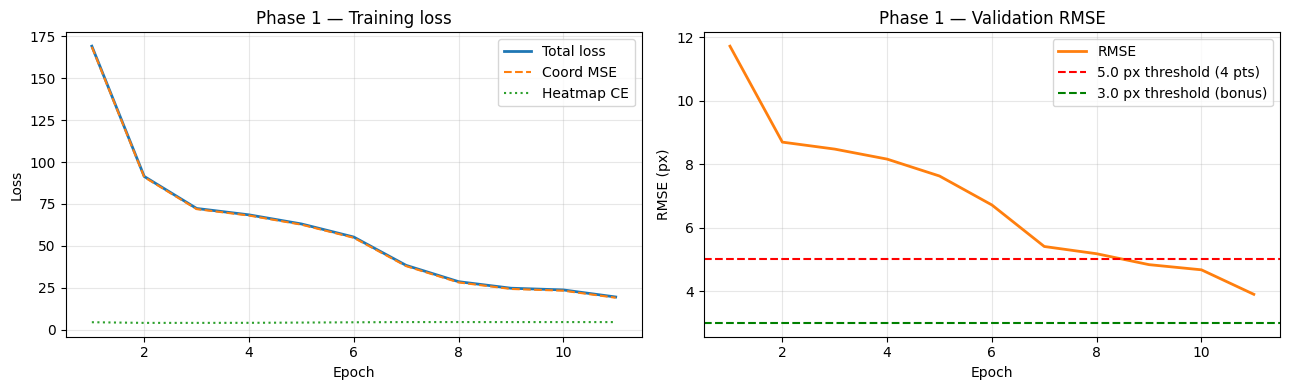

Final Phase 1 RMSE: 3.900 px


In [9]:
# CELL 6: Phase 1 loss curve (required for grading)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(history_p1['epoch'], history_p1['train_loss'],  label='Total loss',    lw=2)
ax.plot(history_p1['epoch'], history_p1['coord_loss'],  label='Coord MSE',     lw=1.5, ls='--')
ax.plot(history_p1['epoch'], history_p1['heatmap_loss'],label='Heatmap CE',    lw=1.5, ls=':')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Phase 1 — Training loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history_p1['epoch'], history_p1['rmse'], color='tab:orange', lw=2, label='RMSE')
ax.axhline(5.0, color='red',    ls='--', lw=1.5, label='5.0 px threshold (4 pts)')
ax.axhline(3.0, color='green',  ls='--', lw=1.5, label='3.0 px threshold (bonus)')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE (px)')
ax.set_title('Phase 1 — Validation RMSE')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Final Phase 1 RMSE: {history_p1['rmse'][-1]:.3f} px")

In [10]:
# CELL 7-v2: Phase 2 — improved (10k eval, 90 epochs)

seed_everything(SEED + 1)

N_EPOCHS_P2B_V2   = 90
EVAL_SAMPLES_P2B  = 10_000

model_p2 = OddShapeLocator(use_offset=True).to(device)
missing, _ = model_p2.load_state_dict(best_state_p1, strict=False)
print(f"Loaded Phase 1 weights — new keys: {len(missing)}  (offset_head only)")
assert all('offset_head' in k for k in missing)

history_p2 = {'epoch': [], 'train_loss': [], 'coord_loss': [],
               'heatmap_loss': [], 'rmse': [], 'phase': []}

# PHASE 2-A: freeze backbone, warm up offset head
print("=" * 65)
print("PHASE 2-A: backbone FROZEN — offset head warmup")
print("=" * 65)

for name, param in model_p2.named_parameters():
    param.requires_grad = ('offset_head' in name)

optimizer_2a = AdamW(
    [p for p in model_p2.parameters() if p.requires_grad],
    lr=LR_P2_FROZEN, weight_decay=WEIGHT_DECAY,
)
sched_2a  = CosineAnnealingWarmRestarts(optimizer_2a, T_0=N_EPOCHS_P2_FROZEN * steps_per_epoch)
scaler_2a = torch.amp.GradScaler('cuda', enabled=USE_AMP)  # fixed

print(f"{'Epoch':>6}  {'Loss':>8}  {'CoordL':>8}  {'HeatL':>8}  {'RMSE':>8}")
print("-" * 55)

model_p2.train()
for epoch in range(1, N_EPOCHS_P2_FROZEN + 1):
    ds     = OddXYDataset(num_samples=N_TRAIN_SAMPLES)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=2,
                        pin_memory=(device.type=='cuda'), worker_init_fn=worker_init_fn)
    rl = rc = rh = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)  # [B, 1, 64, 64], [B, 2]
        optimizer_2a.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):  # fixed
            pred, probs = model_p2(images)   # [B, 2], [B, 144]
            loss, c_l, h_l = compute_loss(pred, probs, labels, model_p2, use_heatmap=True)  # scalar, float, float
        scaler_2a.scale(loss).backward()
        scaler_2a.unscale_(optimizer_2a)
        torch.nn.utils.clip_grad_norm_(model_p2.parameters(), max_norm=1.0)
        scaler_2a.step(optimizer_2a); scaler_2a.update(); sched_2a.step()
        rl += loss.item(); rc += c_l; rh += h_l
    n    = len(loader)
    rmse = evaluate_rmse(model_p2, n_samples=5_000)
    print(f"{epoch:>6}  {rl/n:>8.4f}  {rc/n:>8.4f}  {rh/n:>8.4f}  {rmse:>8.3f}")
    history_p2['epoch'].append(epoch); history_p2['train_loss'].append(rl/n)
    history_p2['coord_loss'].append(rc/n); history_p2['heatmap_loss'].append(rh/n)
    history_p2['rmse'].append(rmse); history_p2['phase'].append('2a')

# PHASE 2-B: unfreeze all, full fine-tuning
print("\n" + "=" * 65)
print(f"PHASE 2-B: UNFROZEN — {N_EPOCHS_P2B_V2} epochs, {EVAL_SAMPLES_P2B//1000}k eval")
print("=" * 65)

for param in model_p2.parameters():
    param.requires_grad = True

optimizer_2b = AdamW(model_p2.parameters(), lr=LR_P2_FULL, weight_decay=WEIGHT_DECAY)
sched_2b = CosineAnnealingWarmRestarts(
    optimizer_2b, T_0=10 * steps_per_epoch, eta_min=LR_P2_FULL * 0.01,
)
scaler_2b     = torch.amp.GradScaler('cuda', enabled=USE_AMP)  # fixed
best_rmse_p2  = float('inf')
best_state_p2 = None
p2b_start     = N_EPOCHS_P2_FROZEN

print(f"{'Epoch':>6}  {'Loss':>8}  {'CoordL':>8}  {'HeatL':>8}  {'RMSE(10k)':>10}  {'τ':>6}")
print("-" * 68)

model_p2.train()
for epoch in range(1, N_EPOCHS_P2B_V2 + 1):
    ds     = OddXYDataset(num_samples=N_TRAIN_SAMPLES)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=2,
                        pin_memory=(device.type=='cuda'), worker_init_fn=worker_init_fn)
    rl = rc = rh = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)  # [B, 1, 64, 64], [B, 2]
        optimizer_2b.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            pred, probs = model_p2(images)   # [B, 2], [B, 144]
            loss, c_l, h_l = compute_loss(pred, probs, labels, model_p2, use_heatmap=True)  # scalar, float, float
        scaler_2b.scale(loss).backward()
        scaler_2b.unscale_(optimizer_2b)
        torch.nn.utils.clip_grad_norm_(model_p2.parameters(), max_norm=1.0)
        scaler_2b.step(optimizer_2b); scaler_2b.update(); sched_2b.step()
        rl += loss.item(); rc += c_l; rh += h_l

    n            = len(loader)
    rmse         = evaluate_rmse(model_p2, n_samples=EVAL_SAMPLES_P2B)  # 10k
    global_epoch = p2b_start + epoch
    tau          = model_p2.log_temperature.exp().item()

    history_p2['epoch'].append(global_epoch)
    history_p2['train_loss'].append(rl/n); history_p2['coord_loss'].append(rc/n)
    history_p2['heatmap_loss'].append(rh/n); history_p2['rmse'].append(rmse)
    history_p2['phase'].append('2b')

    print(f"{global_epoch:>6}  {rl/n:>8.4f}  {rc/n:>8.4f}  {rh/n:>8.4f}  {rmse:>10.3f}  {tau:>6.3f}")

    if rmse < best_rmse_p2:
        best_rmse_p2  = rmse
        best_state_p2 = deepcopy(model_p2.state_dict())
        torch.save(best_state_p2, '/content/best_single_model.pt')  # save to disk

model_p2.load_state_dict(best_state_p2)
print(f"\nBest Phase 2 RMSE (10k): {best_rmse_p2:.3f} px")
print("Checkpoint saved to /content/best_single_model.pt")

Loaded Phase 1 weights — new keys: 6  (offset_head only)
PHASE 2-A: backbone FROZEN — offset head warmup
 Epoch      Loss    CoordL     HeatL      RMSE
-------------------------------------------------------
     1   15.9918   15.5513    4.4048     3.620
     2   14.3989   13.9568    4.4209     3.763
     3   14.6922   14.2502    4.4192     3.602
     4   14.3494   13.9084    4.4092     3.751
     5   14.1177   13.6757    4.4201     3.525

PHASE 2-B: UNFROZEN — 90 epochs, 10k eval
 Epoch      Loss    CoordL     HeatL   RMSE(10k)       τ
--------------------------------------------------------------------
     6   12.7758   12.3339    4.4191       3.231   0.939
     7   11.1825   10.7475    4.3498       3.091   0.937
     8   10.5284   10.0844    4.4405       2.962   0.936
     9   10.6491   10.2043    4.4486       2.977   0.935
    10    9.4819    9.0388    4.4315       2.838   0.935
    11    9.7893    9.3446    4.4465       2.861   0.934
    12    9.2097    8.7651    4.4461       2.9

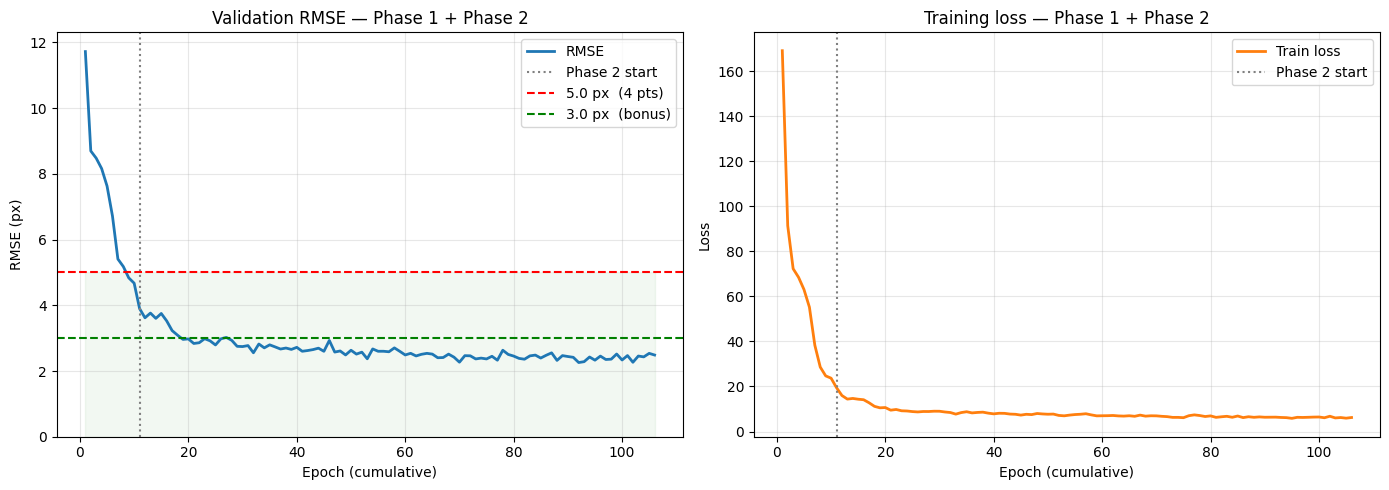

Phase 2 best RMSE (10k eval): 2.258 px


In [11]:
# CELL 9: Combined loss curves — Phase 1 + Phase 2

all_epochs   = (list(history_p1['epoch']) +
                [e + history_p1['epoch'][-1] for e in history_p2['epoch']])
all_rmse     = history_p1['rmse']       + history_p2['rmse']
all_loss     = history_p1['train_loss'] + history_p2['train_loss']
phase2_start = history_p1['epoch'][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(all_epochs, all_rmse, color='tab:blue', lw=2, label='RMSE')
ax.axvline(phase2_start, color='gray', ls=':', lw=1.5, label='Phase 2 start')
ax.axhline(5.0, color='red',   ls='--', lw=1.5, label='5.0 px  (4 pts)')
ax.axhline(3.0, color='green', ls='--', lw=1.5, label='3.0 px  (bonus)')
ax.fill_between(all_epochs, 0, 5.0, alpha=0.05, color='green')
ax.set_xlabel('Epoch (cumulative)')
ax.set_ylabel('RMSE (px)')
ax.set_title('Validation RMSE — Phase 1 + Phase 2')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

ax = axes[1]
ax.plot(all_epochs, all_loss, color='tab:orange', lw=2, label='Train loss')
ax.axvline(phase2_start, color='gray', ls=':', lw=1.5, label='Phase 2 start')
ax.set_xlabel('Epoch (cumulative)')
ax.set_ylabel('Loss')
ax.set_title('Training loss — Phase 1 + Phase 2')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Phase 2 best RMSE (10k eval): {best_rmse_p2:.3f} px')


Model RMSE on 3000 samples: 2.338 px

Selected examples (errors are now real model errors):
  [EASY] sample 134  error=0.02 px
  [EASY] sample 299  error=0.03 px
  [MED] sample 107  error=0.93 px
  [MED] sample  26  error=0.93 px
  [HARD] sample  24  error=29.54 px
  [HARD] sample  41  error=31.14 px


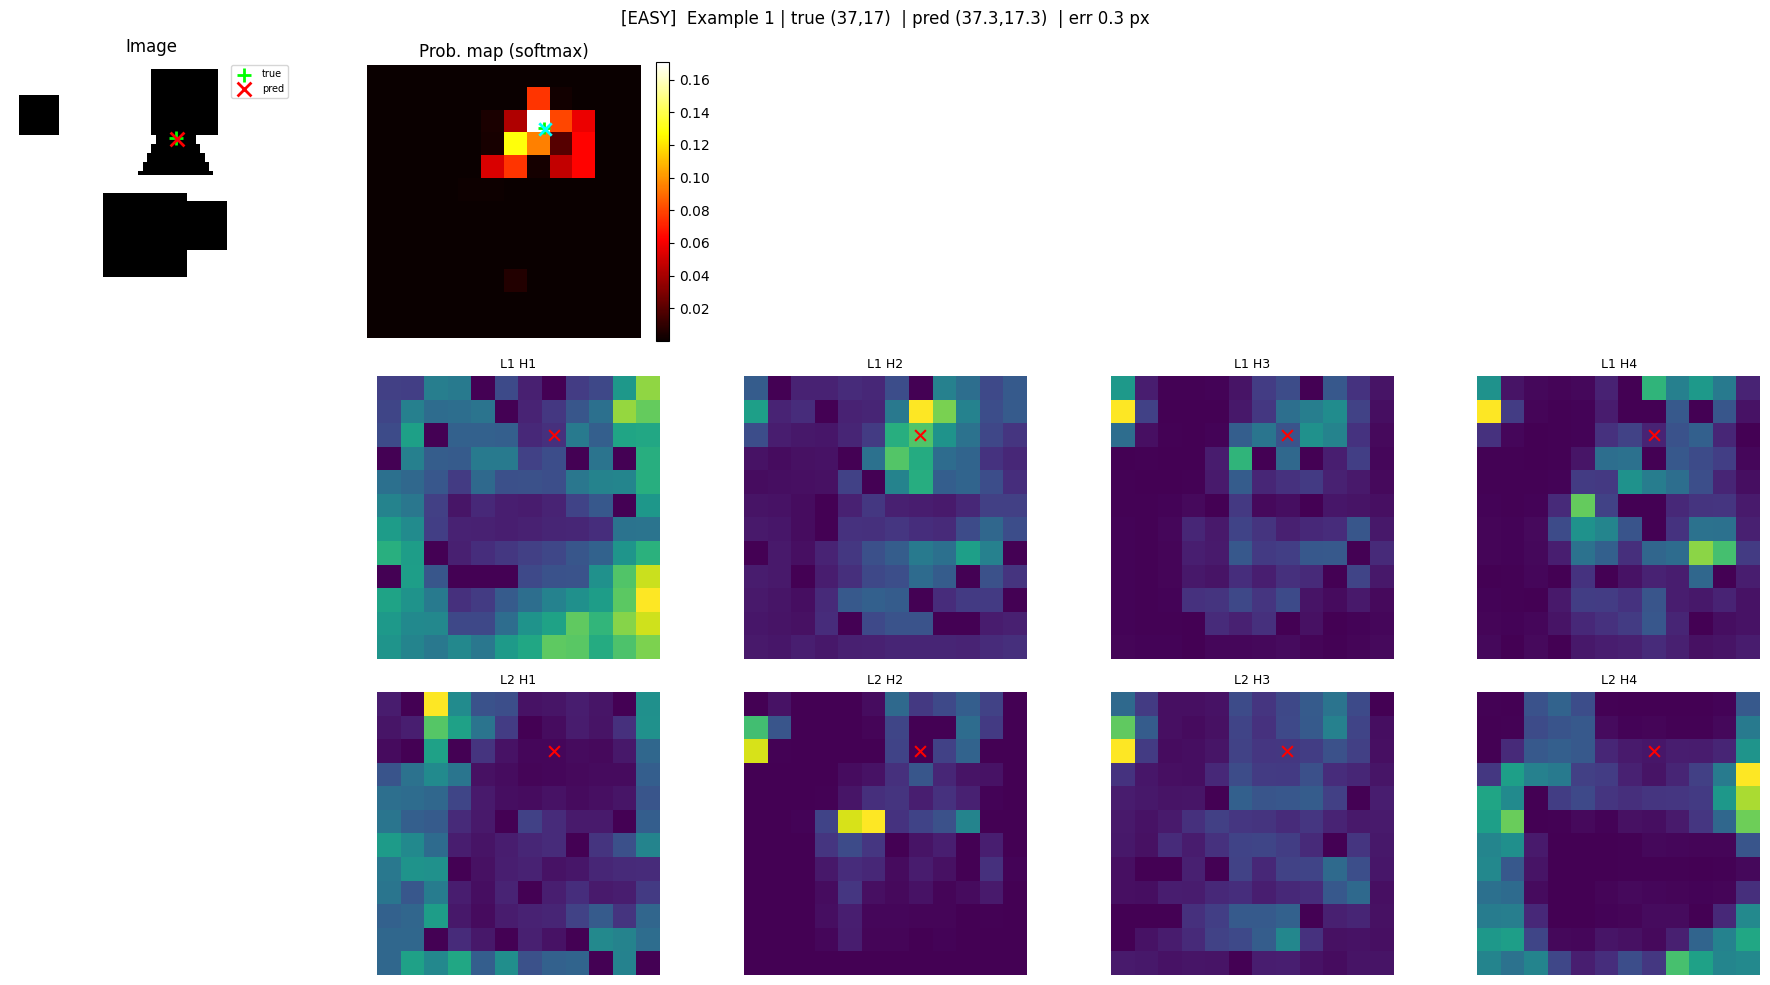

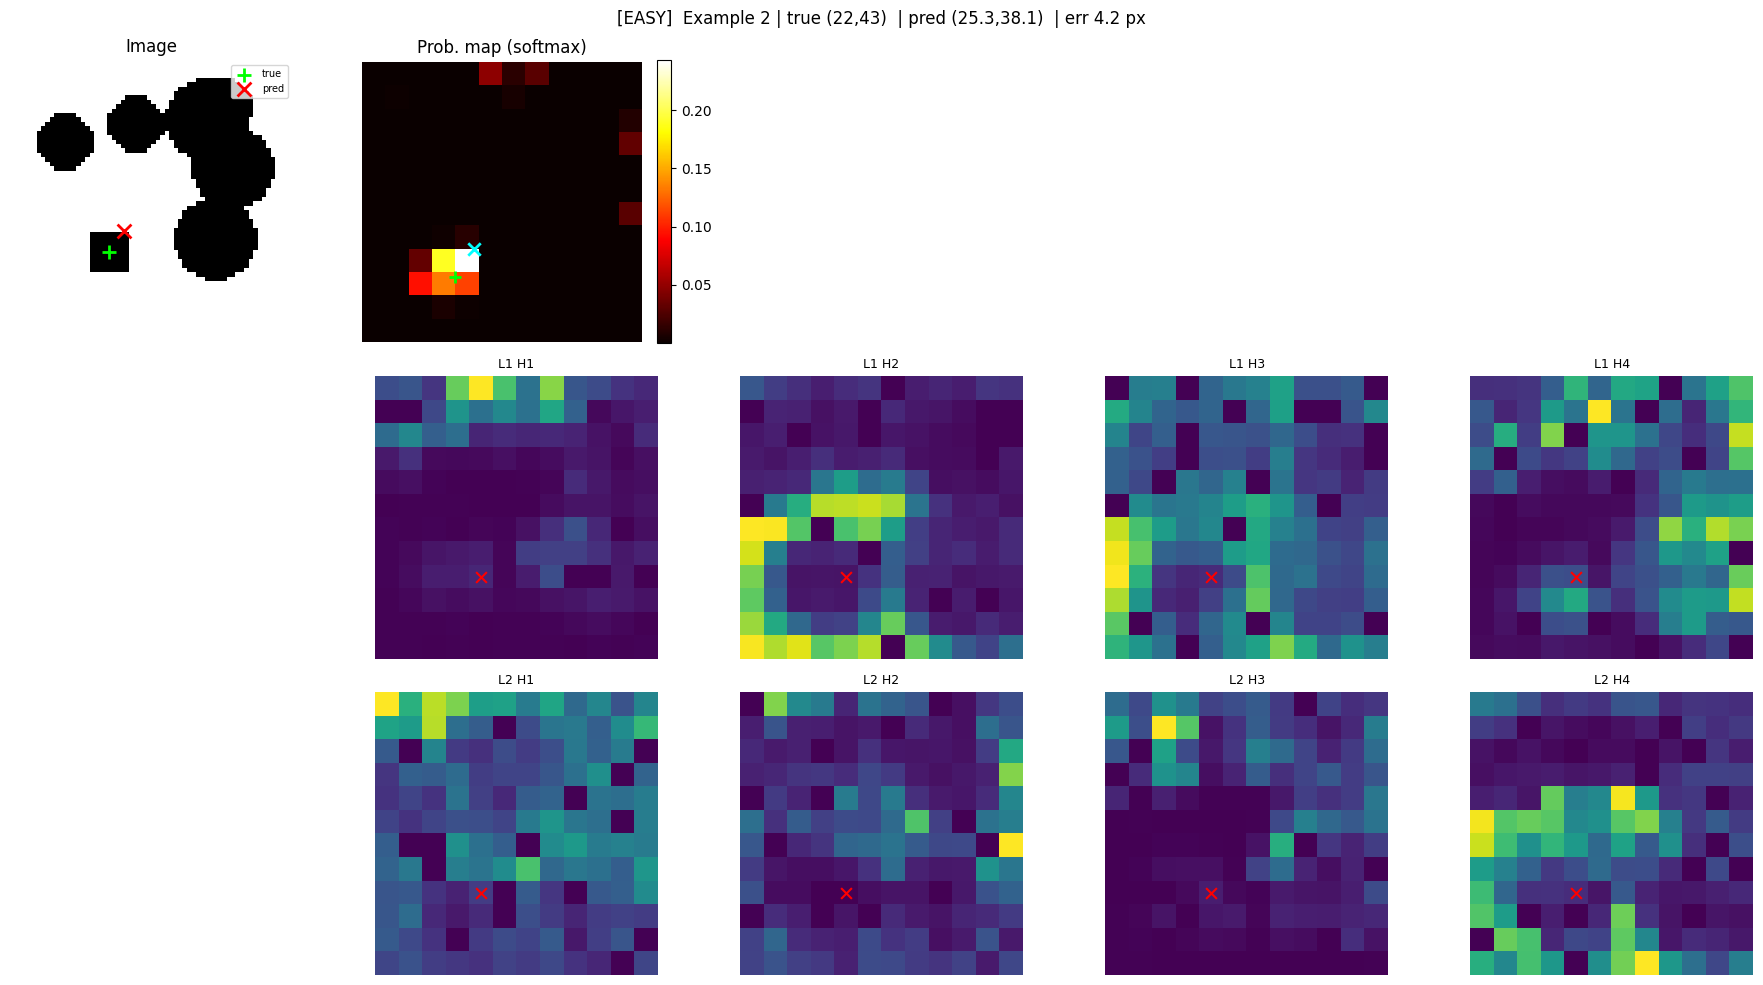

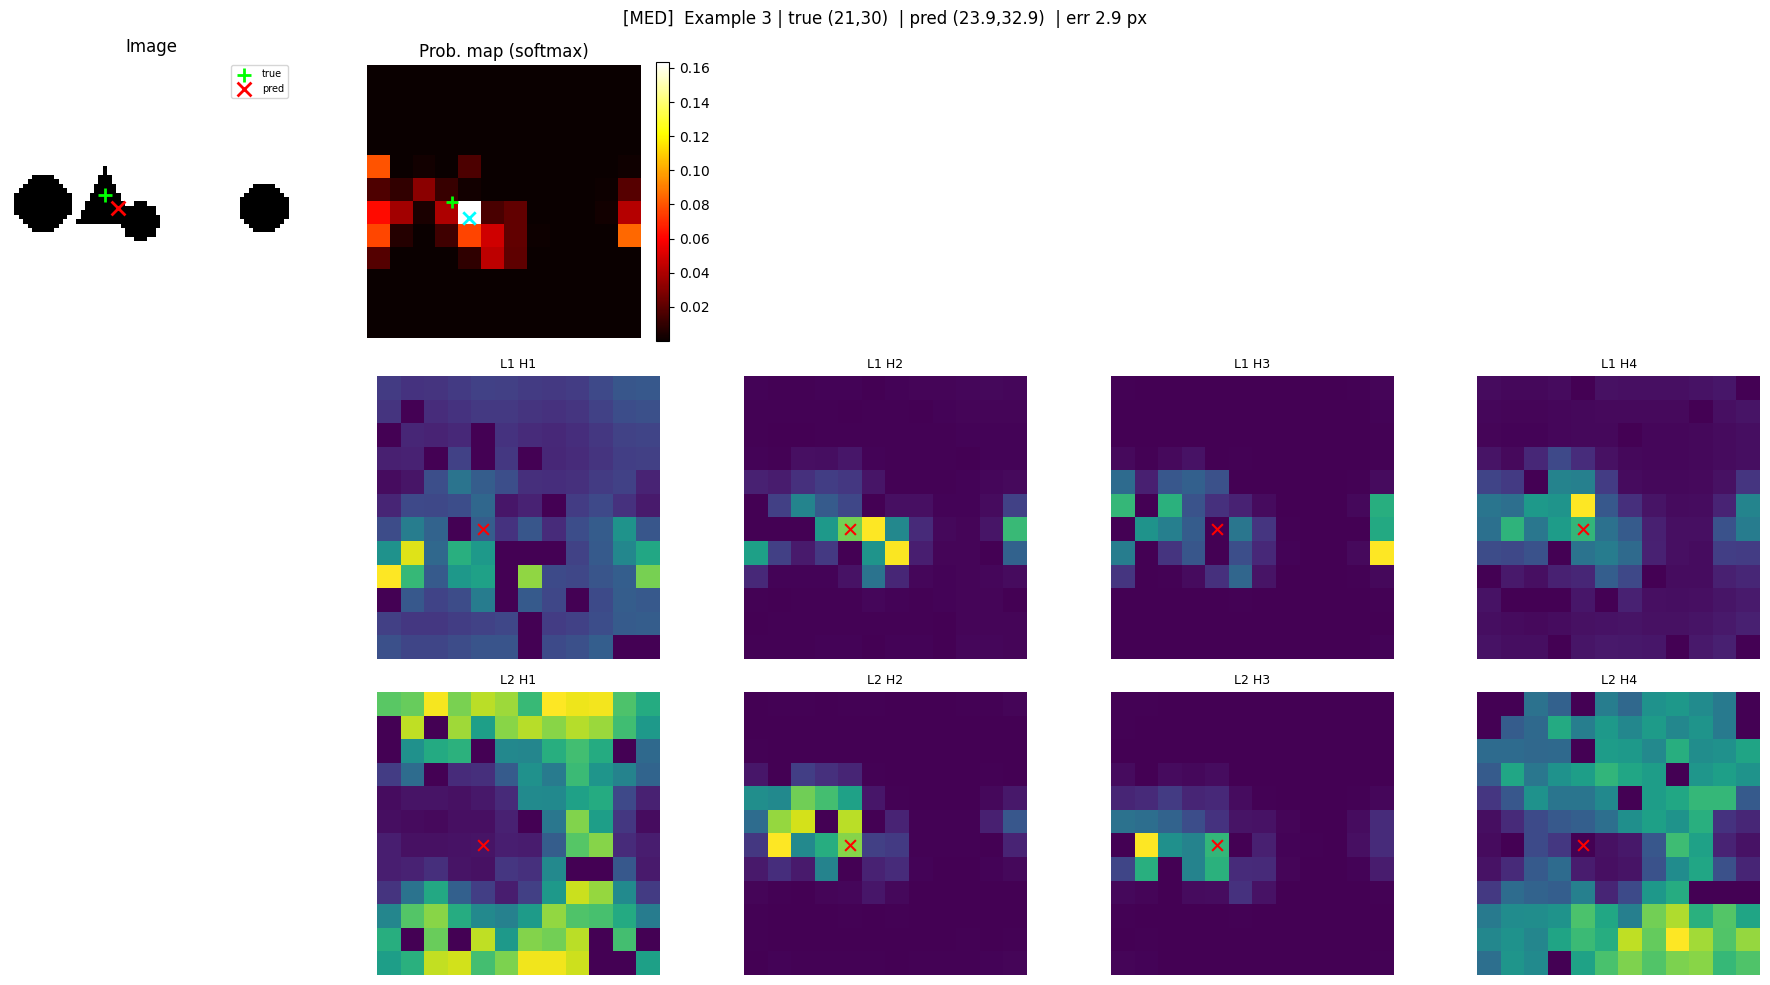

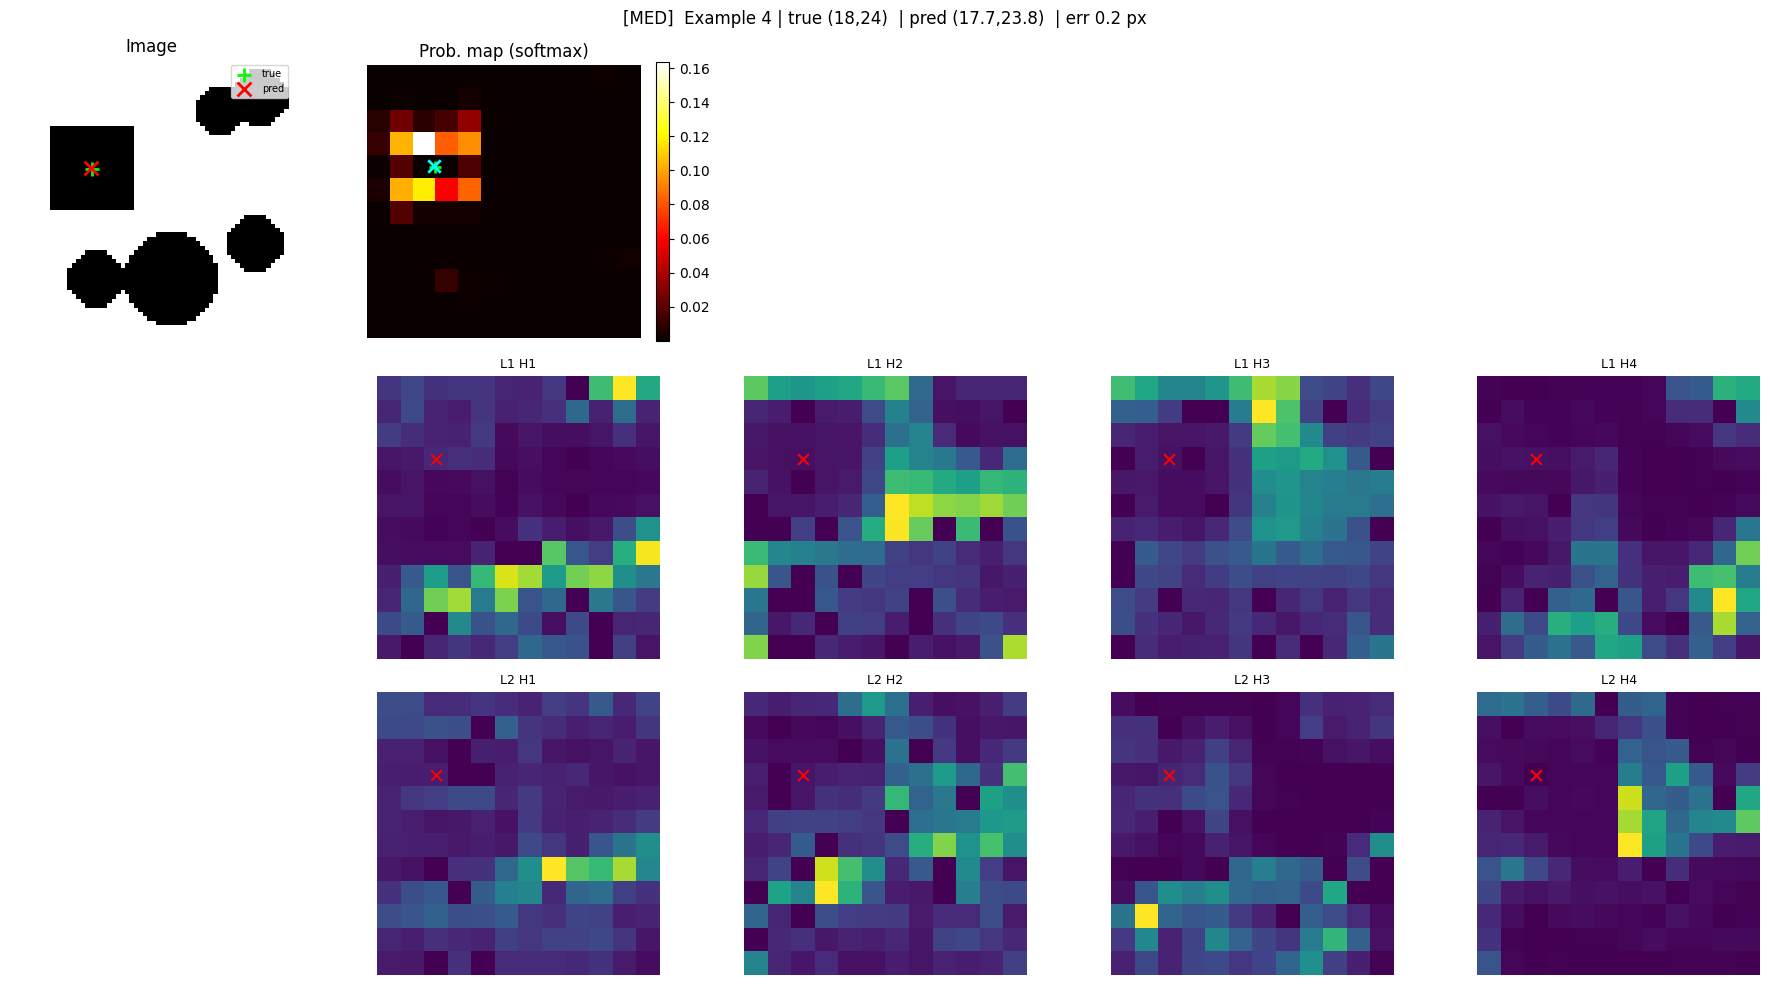

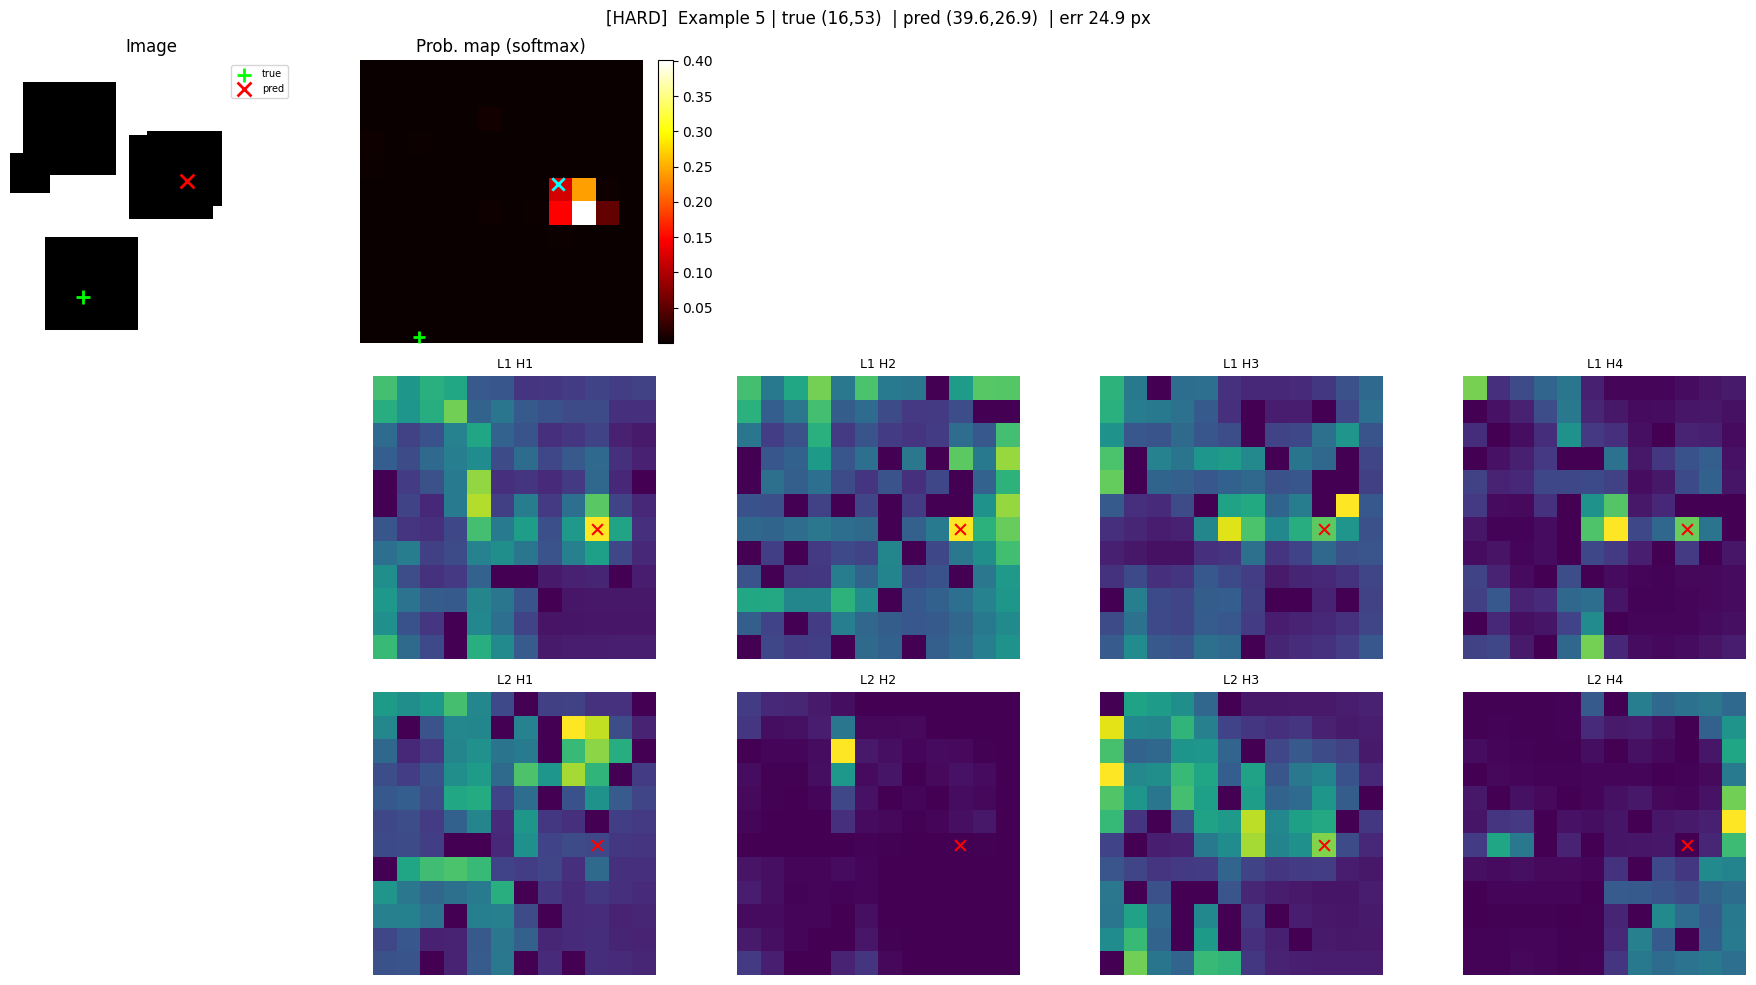

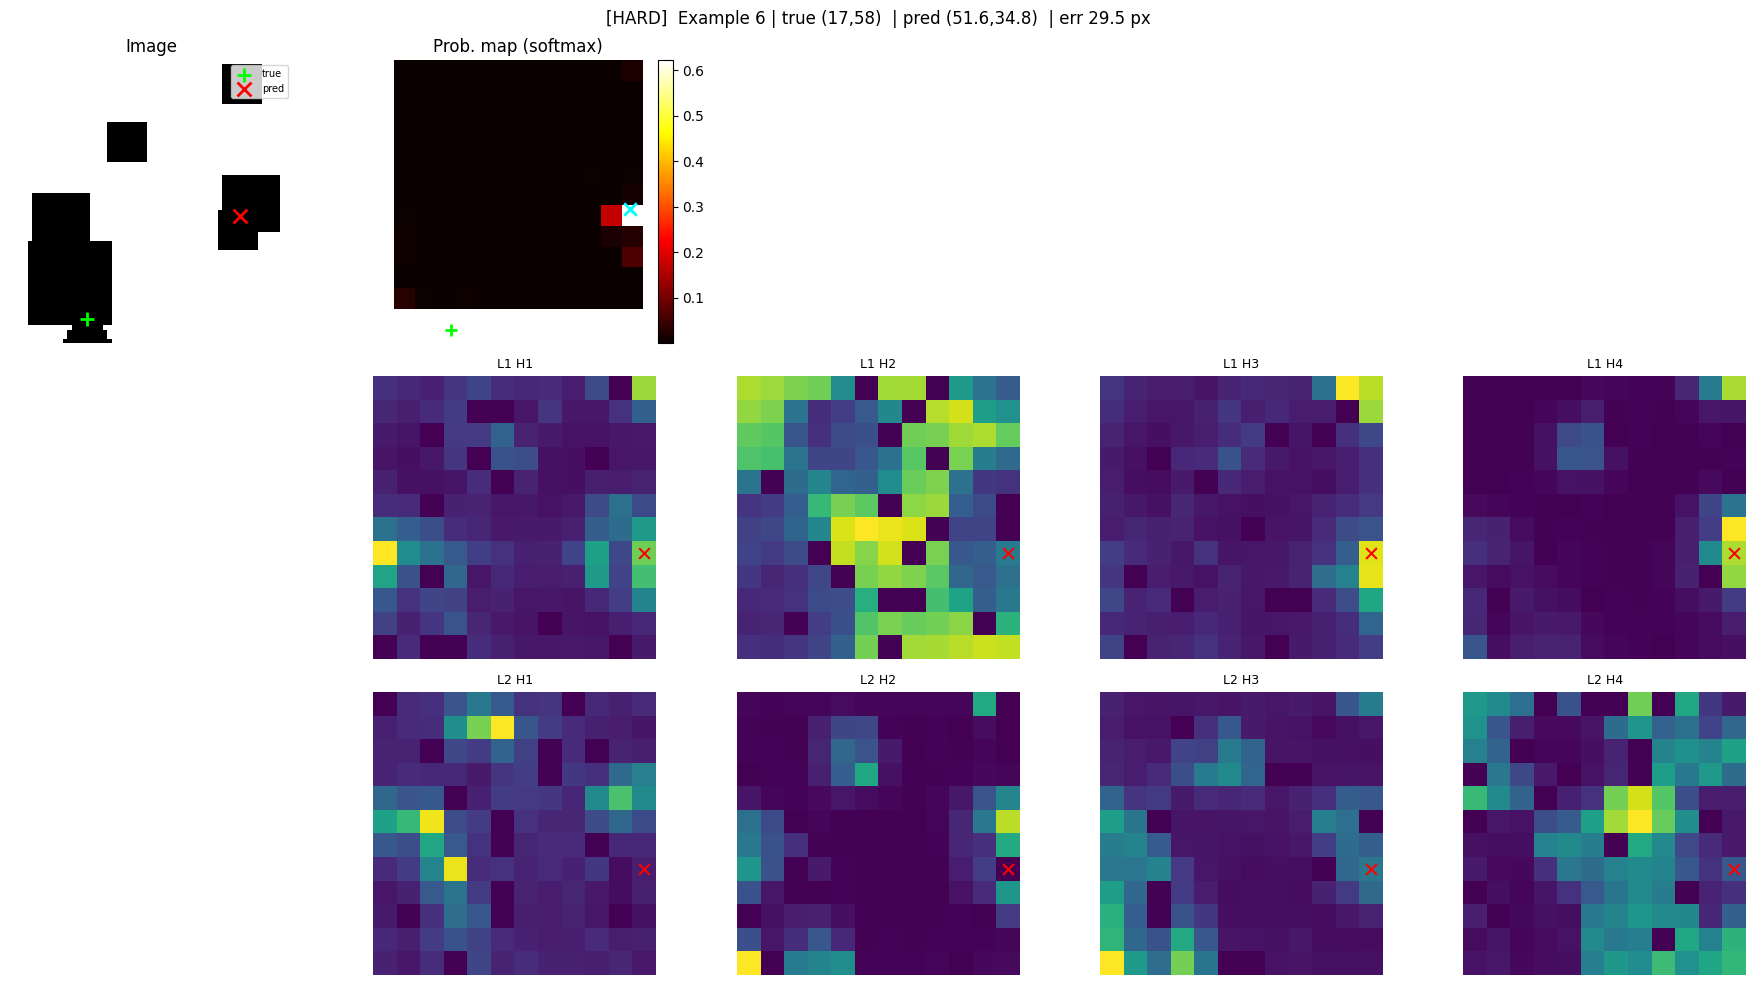


── Attention entropy per head ──
   (max possible = log(144) ≈ 4.97;  lower = sharper)

  Layer 1: H1=4.540  H2=4.603  H3=4.282  H4=4.143
  Layer 2: H1=4.509  H2=4.443  H3=4.377  H4=4.672

── Prob-map sharpness: easy vs hard ──
  easy (low err)          entropy=2.431  peak_prob=0.207
  hard (high err)         entropy=1.520  peak_prob=0.512


In [13]:
# CELL 10: Attention visualization

model_viz = OddShapeLocator(use_offset=True).to(device)
model_viz.load_state_dict(
    torch.load('/content/best_single_model.pt', map_location=device)
)
model_viz.eval()

quick_rmse = evaluate_rmse(model_viz, n_samples=3000)
print(f'Model RMSE on 3000 samples: {quick_rmse:.3f} px\n')

seed_everything(SEED)
N_SEARCH  = 500
ds_search = OddXYDataset(num_samples=N_SEARCH)

search_data   = [ds_search[i] for i in range(N_SEARCH)]       # 500 (img, label) tuples
search_images = torch.stack([x[0] for x in search_data])      # [500, 1, 64, 64]
search_labels = torch.stack([x[1] for x in search_data])      # [500, 2]

with torch.no_grad():
    preds_all = []
    for i in range(0, N_SEARCH, 64):
        batch = search_images[i:i+64].to(device)
        p, _  = model_viz(batch)
        preds_all.append(p.cpu())
    preds_all = torch.cat(preds_all, dim=0)   # [500, 2]

per_example_err = torch.sqrt(
    ((preds_all - search_labels) ** 2).sum(dim=-1)   # [500]
)

ranked     = per_example_err.argsort()
easy_idx   = ranked[:2].tolist()
medium_idx = ranked[N_SEARCH//2 - 1 : N_SEARCH//2 + 1].tolist()
hard_idx   = ranked[-2:].tolist()
selected   = easy_idx + medium_idx + hard_idx

difficulty_labels = ['EASY'] * 2 + ['MED'] * 2 + ['HARD'] * 2

print("Selected examples (errors are now real model errors):")
for idx, diff in zip(selected, difficulty_labels):
    print(f"  [{diff}] sample {idx:>3}  error={per_example_err[idx]:.2f} px")

viz_images = search_images[selected].to(device)   # [6, 1, 64, 64]
viz_labels = search_labels[selected].to(device)   # [6, 2]

with torch.no_grad():
    viz_pred, viz_probs, viz_attn = model_viz(viz_images, return_attn=True)
    # viz_pred  : [6, 2]
    # viz_probs : [6, 144]
    # viz_attn  : list of N_LAYERS tensors, each [6, N_HEADS, 144, 144]

for i in range(len(selected)):
    err = math.sqrt(F.mse_loss(viz_pred[i:i+1], viz_labels[i:i+1]).item())
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(
        f'[{difficulty_labels[i]}]  Example {i+1} | '
        f'true ({viz_labels[i,0]:.0f},{viz_labels[i,1]:.0f})  '
        f'| pred ({viz_pred[i,0]:.1f},{viz_pred[i,1]:.1f})  '
        f'| err {err:.1f} px',
        fontsize=12
    )

    ax_img  = fig.add_subplot(3, N_HEADS + 1, 1)
    ax_prob = fig.add_subplot(3, N_HEADS + 1, 2)

    img_np = viz_images[i, 0].cpu().numpy()
    ax_img.imshow(img_np, cmap='gray', origin='upper')
    ax_img.scatter(*viz_labels[i].cpu().tolist(), c='lime', s=100,
                   marker='+', lw=2, label='true')
    ax_img.scatter(*viz_pred[i].cpu().tolist(),   c='red',  s=100,
                   marker='x', lw=2, label='pred')
    ax_img.legend(fontsize=7, loc='upper right')
    ax_img.set_title('Image')
    ax_img.axis('off')

    prob_map = viz_probs[i].cpu().view(N_GRID, N_GRID).numpy()   # [12, 12]
    im = ax_prob.imshow(
        prob_map, cmap='hot', origin='upper',
        extent=[RF_OFFSET - RF_STRIDE/2,
                RF_OFFSET + (N_GRID - 0.5) * RF_STRIDE,
                RF_OFFSET + (N_GRID - 0.5) * RF_STRIDE,
                RF_OFFSET - RF_STRIDE/2]
    )
    ax_prob.scatter(*viz_labels[i].cpu().tolist(), c='lime', s=80, marker='+', lw=2)
    ax_prob.scatter(*viz_pred[i].cpu().tolist(),   c='cyan', s=80, marker='x', lw=2)
    ax_prob.set_title('Prob. map (softmax)')
    ax_prob.axis('off')
    plt.colorbar(im, ax=ax_prob, fraction=0.046)

    best_token = viz_probs[i].argmax().item()
    best_row   = best_token // N_GRID
    best_col   = best_token %  N_GRID

    for layer_idx in range(N_LAYERS):
        attn_layer = viz_attn[layer_idx][i]
        for head_idx in range(N_HEADS):
            subplot_idx = (layer_idx + 1) * (N_HEADS + 1) + head_idx + 2
            ax  = fig.add_subplot(3, N_HEADS + 1, subplot_idx)
            attn_row = attn_layer[head_idx, best_token].numpy()   # [144]
            attn_map = attn_row.reshape(N_GRID, N_GRID)            # [12, 12]
            ax.imshow(attn_map, cmap='viridis', origin='upper')
            ax.scatter(best_col, best_row, c='red', s=60, marker='x', lw=1.5)
            ax.set_title(f'L{layer_idx+1} H{head_idx+1}', fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'attention_{difficulty_labels[i].lower()}_{i+1}.png',
                dpi=110, bbox_inches='tight')
    plt.show()

print('\n── Attention entropy per head ──')
print('   (max possible = log(144) ≈ 4.97;  lower = sharper)\n')
for layer_idx in range(N_LAYERS):
    entropies = []
    for head_idx in range(N_HEADS):
        a   = viz_attn[layer_idx][:, head_idx, :, :]
        ent = -(a * (a + 1e-9).log()).sum(-1).mean().item()
        entropies.append(ent)
    print(f'  Layer {layer_idx+1}: ' +
          '  '.join(f'H{j+1}={e:.3f}' for j, e in enumerate(entropies)))

print('\n── Prob-map sharpness: easy vs hard ──')
for label, idxs in [('easy (low err)', [0, 1]), ('hard (high err)', [4, 5])]:
    p = viz_probs[idxs]
    ent  = -(p * (p + 1e-9).log()).sum(-1).mean().item()
    peak = p.max(dim=-1).values.mean().item()
    print(f'  {label:22s}  entropy={ent:.3f}  peak_prob={peak:.3f}')

del model_viz


## 4. Attention and Error Analysis

Analysis of the attention matrices and the resulting probability distributions reveals fascinating, and sometimes counterintuitive, behaviors of the model.

### 4.1. The Failure Mode: Complete Occlusion
When analyzing the worst-performing examples (errors of $29–31$ px), one might expect the model to be highly uncertain, producing flat, high-entropy attention maps. Counterintuitively, the hard examples show sharper probability maps (entropy = $1.52$, peak probability = $0.51$) than the easy examples (entropy = $2.43$, peak probability = $0.21$).

**Why does this happen?** This reveals the model's primary failure mode. When the odd shape is completely occluded by regular shapes, the model physically cannot find it. Instead, it identifies the most "suspicious" visible token—typically a regular shape partially overlapping another, creating an unusual boundary or artifact. Because this artifact is the only outlier in the scene, the model confidently concentrates its probability mass on this incorrect token.

This behavior perfectly explains the **bimodal error distribution**: the median error across 500 random samples is merely **$0.93$ px**, indicating that the model localizes the odd shape with sub-pixel accuracy in the vast majority of cases. However, a small fraction of examples with complete occlusion produces catastrophic errors of $20–60$ px. Because RMSE squares the errors, these few catastrophic failures dominate the metric, pulling the overall score from $\sim 1.0$ px up to $\sim 2.3$ px.

### 4.2. The Success Mode: Diffuse-But-Correct
In the easy, highly accurate examples, the probability mass does not collapse to a single point; rather, it spreads across a small neighborhood around the correct position.

**Why is this optimal?** The odd shape spans several receptive fields. The soft-argmax mechanism uses the weighted average of these nearby tokens to interpolate a much more precise coordinate prediction than a single, sharp spike would allow.

### 4.3. How Attention Solves the Problem
The attention entropy in successful cases shows moderate focus rather than extreme concentration (e.g., Layer 1, Head 4 operates at an entropy of $4.04$ out of a maximum $\sim 4.97$). This is consistent with tokens gathering comparative evidence from the full scene.

**Crucial interpretation:** The self-attention mechanism does *not* directly "select" the odd token. Instead, it provides every token with a rich, comparison-aware representation. It maps the local patch against the global context. Once this context is built, it is the job of the classifier MLP to evaluate these enriched features and amplify the anomaly signal into the final spatial probability map.

In [ ]:

# CELL: Multi-seed training
# Trains 5 full models (Phase 1 + Phase 2) with different seeds.

SEED_LIST        = [42, 7, 13, 99, 2024]
N_EPOCHS_P1_ENS  = 60
N_EPOCHS_P2A_ENS = 5
N_EPOCHS_P2B_ENS = 70

EVAL_ENS         = 8_000

ensemble_states = {}
ensemble_rmses  = {}

for trial_idx, trial_seed in enumerate(SEED_LIST):
    print(f"\n{'#'*65}")
    print(f"  SEED {trial_seed}   ({trial_idx+1}/{len(SEED_LIST)})")
    print(f"{'#'*65}")

    seed_everything(trial_seed)

    #PHASE 1
    if trial_seed == SEED and best_state_p1 is not None:
        print(f"  → Reusing Phase 1 checkpoint from SEED={SEED} (RMSE {best_rmse_p1:.3f} px)")
        p1_state = best_state_p1
    else:
        m1  = OddShapeLocator(use_offset=False).to(device)
        op1 = AdamW(m1.parameters(), lr=LR_P1, weight_decay=WEIGHT_DECAY)
        sc1 = CosineAnnealingWarmRestarts(op1, T_0=10*steps_per_epoch, eta_min=LR_P1*0.01)
        gz1 = torch.amp.GradScaler('cuda', enabled=USE_AMP)

        best_p1r, best_p1s = float('inf'), None
        m1.train()
        print(f"  Phase 1 (max {N_EPOCHS_P1_ENS} epochs):")
        for ep in range(1, N_EPOCHS_P1_ENS + 1):
            ds  = OddXYDataset(num_samples=N_TRAIN_SAMPLES)
            ldl = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=2,
                             pin_memory=(device.type=='cuda'), worker_init_fn=worker_init_fn)
            for imgs, lbs in ldl:
                imgs, lbs = imgs.to(device), lbs.to(device)  # [B, 1, 64, 64], [B, 2]
                op1.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', enabled=USE_AMP):
                    p, pr = m1(imgs)   # [B, 2], [B, 144]
                    loss, _, _ = compute_loss(p, pr, lbs, m1, use_heatmap=True)  # scalar
                gz1.scale(loss).backward()
                gz1.unscale_(op1)
                torch.nn.utils.clip_grad_norm_(m1.parameters(), max_norm=1.0)
                gz1.step(op1); gz1.update(); sc1.step()
            r1 = evaluate_rmse(m1, n_samples=3_000)
            print(f"    ep {ep:>3}  rmse={r1:.3f}")
            if r1 < best_p1r:
                best_p1r = r1; best_p1s = deepcopy(m1.state_dict())
            if r1 < TARGET_RMSE_P1:
                print(f"    → Phase 1 done at ep {ep}  (RMSE {r1:.3f} < 4.0)")
                break

        p1_state = best_p1s
        del m1, op1, sc1, gz1
        torch.cuda.empty_cache()

    #PHASE 2-A: freeze backbone
    m2 = OddShapeLocator(use_offset=True).to(device)
    m2.load_state_dict(p1_state, strict=False)

    for name, param in m2.named_parameters():
        param.requires_grad = ('offset_head' in name)

    op2a = AdamW([p for p in m2.parameters() if p.requires_grad], lr=LR_P2_FROZEN, weight_decay=WEIGHT_DECAY)
    sc2a = CosineAnnealingWarmRestarts(op2a, T_0=N_EPOCHS_P2A_ENS * steps_per_epoch)
    gz2a = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    m2.train()
    print(f"  Phase 2-A ({N_EPOCHS_P2A_ENS} frozen epochs):")
    for ep in range(1, N_EPOCHS_P2A_ENS + 1):
        ds  = OddXYDataset(num_samples=N_TRAIN_SAMPLES)
        ldl = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=2,
                         pin_memory=(device.type=='cuda'), worker_init_fn=worker_init_fn)
        for imgs, lbs in ldl:
            imgs, lbs = imgs.to(device), lbs.to(device)  # [B, 1, 64, 64], [B, 2]
            op2a.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                p, pr = m2(imgs)   # [B, 2], [B, 144]
                loss, _, _ = compute_loss(p, pr, lbs, m2, use_heatmap=True)  # scalar
            gz2a.scale(loss).backward()
            gz2a.unscale_(op2a)
            torch.nn.utils.clip_grad_norm_(m2.parameters(), max_norm=1.0)
            gz2a.step(op2a); gz2a.update(); sc2a.step()

    r2a = evaluate_rmse(m2, n_samples=3_000)
    print(f"    After 2-A: {r2a:.3f} px")
    del op2a, sc2a, gz2a

    #PHASE 2-B: full fine-tuning
    for param in m2.parameters():
        param.requires_grad = True

    op2b = AdamW(m2.parameters(), lr=LR_P2_FULL, weight_decay=WEIGHT_DECAY)
    sc2b = CosineAnnealingWarmRestarts(op2b, T_0=10*steps_per_epoch, eta_min=LR_P2_FULL*0.01)
    gz2b = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    best_rmse_seed  = float('inf')
    best_state_seed = None

    m2.train()
    print(f"  Phase 2-B ({N_EPOCHS_P2B_ENS} epochs, {EVAL_ENS//1000}k eval):")
    for ep in range(1, N_EPOCHS_P2B_ENS + 1):
        ds  = OddXYDataset(num_samples=N_TRAIN_SAMPLES)
        ldl = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=2,
                         pin_memory=(device.type=='cuda'), worker_init_fn=worker_init_fn)
        for imgs, lbs in ldl:
            imgs, lbs = imgs.to(device), lbs.to(device)  # [B, 1, 64, 64], [B, 2]
            op2b.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                p, pr = m2(imgs)   # [B, 2], [B, 144]
                loss, _, _ = compute_loss(p, pr, lbs, m2, use_heatmap=True)  # scalar
            gz2b.scale(loss).backward()
            gz2b.unscale_(op2b)
            torch.nn.utils.clip_grad_norm_(m2.parameters(), max_norm=1.0)
            gz2b.step(op2b); gz2b.update(); sc2b.step()

        rmse = evaluate_rmse(m2, n_samples=EVAL_ENS)  # float
        if ep % 10 == 0 or ep <= 5:
            print(f"    ep {ep:>3}  rmse={rmse:.3f}")
        if rmse < best_rmse_seed:
            best_rmse_seed  = rmse
            best_state_seed = deepcopy(m2.state_dict())

    save_path = f'/content/ensemble_seed_{trial_seed}.pt'
    torch.save(best_state_seed, save_path)
    ensemble_states[trial_seed] = best_state_seed
    ensemble_rmses[trial_seed]  = best_rmse_seed
    print(f"  ✓ Best RMSE: {best_rmse_seed:.3f} px  →  saved to {save_path}")

    del m2, op2b, sc2b, gz2b, best_state_seed
    torch.cuda.empty_cache()
print(f"\n{'='*50}")
print("Multi-seed training complete:")
for s in SEED_LIST:
    print(f"  seed {s:>5}:  {ensemble_rmses[s]:.3f} px")
print(f"  Mean:   {sum(ensemble_rmses.values())/len(ensemble_rmses):.3f} px")
print(f"{'='*50}")


#################################################################
  SEED 42   (1/5)
#################################################################
  → Reusing Phase 1 checkpoint from SEED=42 (RMSE 3.729 px)
  Phase 2-A (5 frozen epochs):
    After 2-A: 3.532 px
  Phase 2-B (70 epochs, 8k eval):
    ep   1  rmse=3.199
    ep   2  rmse=3.048
    ep   3  rmse=3.129
    ep   4  rmse=2.947
    ep   5  rmse=2.985
    ep  10  rmse=3.031
    ep  20  rmse=2.712
    ep  30  rmse=2.514
    ep  40  rmse=2.541
    ep  50  rmse=2.488
    ep  60  rmse=2.516
    ep  70  rmse=2.451
  ✓ Best RMSE: 2.271 px  →  saved to /content/ensemble_seed_42.pt

#################################################################
  SEED 7   (2/5)
#################################################################
  Phase 1 (max 60 epochs):
    ep   1  rmse=11.453
    ep   2  rmse=8.753
    ep   3  rmse=8.468
    ep   4  rmse=8.014
    ep   5  rmse=7.720
    ep   6  rmse=7.026
    ep   7  rmse=6.286
    ep   8  rmse=5.

In [ ]:
# CELL: Ensemble evaluation on 25,000 samples

ensemble_models = []
for trial_seed in SEED_LIST:
    m = OddShapeLocator(use_offset=True).to(device)

    if trial_seed in ensemble_states and ensemble_states[trial_seed] is not None:
        m.load_state_dict(ensemble_states[trial_seed])
    else:
        path = f'/content/ensemble_seed_{trial_seed}.pt'
        m.load_state_dict(torch.load(path, map_location=device))
        print(f"  Loaded seed {trial_seed} from disk.")

    m.eval()
    ensemble_models.append(m)

print(f"Loaded {len(ensemble_models)} models.\n")

seed_everything(99999)
ds_test  = OddXYDataset(num_samples=25_000)
loader_t = DataLoader(ds_test, batch_size=512, num_workers=0)

test_images_all, test_labels_all = [], []
for imgs, lbs in loader_t:
    test_images_all.append(imgs)
    test_labels_all.append(lbs)
test_images_all = torch.cat(test_images_all, dim=0)  # [25000, 1, 64, 64]
test_labels_all = torch.cat(test_labels_all, dim=0)  # [25000, 2]

per_model_preds = []
print("Individual model RMSE (25k, same test set):")
for m, trial_seed in zip(ensemble_models, SEED_LIST):
    m.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(test_images_all), 512):
            batch = test_images_all[i:i+512].to(device)  # [B, 1, 64, 64]
            pred, _ = m(batch)                            # [B, 2]
            preds.append(pred.cpu())
    preds = torch.cat(preds, dim=0)                       # [25000, 2]
    rmse  = math.sqrt(F.mse_loss(preds, test_labels_all).item())
    print(f"  seed {trial_seed:>5}:  {rmse:.3f} px")
    per_model_preds.append(preds)

ens_preds = torch.stack(per_model_preds, dim=0).mean(dim=0)
ens_rmse  = math.sqrt(F.mse_loss(ens_preds, test_labels_all).item())

best_single_rmse = None
if 'best_state_p2' in dir() and best_state_p2 is not None:
    m_single = OddShapeLocator(use_offset=True).to(device)
    m_single.load_state_dict(best_state_p2)
    m_single.eval()
    preds_single = []
    with torch.no_grad():
        for i in range(0, len(test_images_all), 512):
            batch = test_images_all[i:i+512].to(device)
            p, _ = m_single(batch)
            preds_single.append(p.cpu())
    preds_single    = torch.cat(preds_single, dim=0)
    best_single_rmse = math.sqrt(F.mse_loss(preds_single, test_labels_all).item())

print(f"\n{'='*50}")
if best_single_rmse is not None:
    print(f"  Best single model (Cell 7v2): {best_single_rmse:.3f} px")
print(f"  Ensemble ({len(SEED_LIST)} seeds):         {ens_rmse:.3f} px")
print()
if ens_rmse < 2.0:
    print("  ★★  SUB-2.0 px ACHIEVED!")
elif ens_rmse < 3.0:
    print("  ★   Bonus threshold met (≤ 3.0 px)")
print(f"{'='*50}")

Loaded 5 models.

Individual model RMSE (25k, same test set):
  seed    42:  2.287 px
  seed     7:  2.372 px
  seed    13:  2.274 px
  seed    99:  2.377 px
  seed  2024:  2.282 px

  Best single model (Cell 7v2): 2.252 px
  Ensemble (5 seeds):         2.169 px

  ★   Bonus threshold met (≤ 3.0 px)
